# DO Classifier Test Notebook

Run the DO scene segmenter, crop detected cards, classify each crop with the DO classical full-card classifier (HSV histogram + HOG + Fourier descriptors), and group predictions using the fixed UNO table geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle). All logic lives in `src/test_classifier/`; this notebook is a thin orchestrator.

In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd() / "project" / "notebooks" / "do" / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


In [2]:
from src.test_classifier import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_single_image_diagnostics,
    run_labeled_benchmark,
)


## Configuration

In [ ]:
# Most-used quick knobs
# Options for IMAGE_SOURCE: "augmented_scene", "train_image", "test_image".
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None

IMG_SIZE_CLASSIFIER = 128
IMG_SIZE_SEGMENTER = 256
FOURIER_COEFFS = 32
CENTER_CROP_FRACTION = 0.62
EVAL_THRESHOLD = 0.50

EVAL_MAX_IMAGES = None
EVAL_RANDOM_SUBSET = True
EVAL_SEED = 42
WORST_K = 25
TOP_K = 25

CFG = TestPipelineConfig(
    image_source=IMAGE_SOURCE,
    image_index=IMAGE_INDEX,
    image_id=IMAGE_ID,
    img_size_classifier=IMG_SIZE_CLASSIFIER,
    img_size_segmenter=IMG_SIZE_SEGMENTER,
    fourier_coeffs=FOURIER_COEFFS,
    center_crop_fraction=CENTER_CROP_FRACTION,
    eval_threshold=EVAL_THRESHOLD,
)

BENCHMARK_CFG = {
    "eval_max_images": EVAL_MAX_IMAGES,
    "eval_random_subset": EVAL_RANDOM_SUBSET,
    "eval_seed": EVAL_SEED,
    "eval_threshold": CFG.eval_threshold,
    "worst_k": WORST_K,
    "top_k": TOP_K,
}

CFG

TestPipelineConfig(image_source='augmented_scene', image_index=0, image_id=None, img_size_classifier=128, img_size_segmenter=256, fourier_coeffs=32, center_crop_fraction=0.62, eval_threshold=0.5)

## Initialize: load segmenter, classifier, classes, and pick an image

In [4]:
state = initialize_test_pipeline(CFG)
state.keys()


Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Segmenter:    /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/scene_segmenter_unet_small.pth
Classifier:   /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_clf_do.pkl
Classes:      /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classes_do.npy
Config:       /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_do_config.json
Classifier feature order: ['hsv_histogram', 'hog_global', 'fourier_global', 'hog_center', 'fourier_center']
[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] SceneUNetSmall: 1,928,417 trainable params
Classifier expects 2212 features per crop.
Loaded card classifier with 54 classes.
Classifier image size: 128
Classifier Fourier coeffs: 32
Classifier center-crop fraction: 0.62
Device: cpu
Image source: augmented_scene
Image id:     aug_scene_00000
Image path:   /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augm

dict_keys(['config', 'project_root', 'training_data', 'models_dir', 'challenge_dir', 'train_images_dir', 'test_images_dir', 'train_csv_path', 'device', 'segmenter', 'segmenter_img_size', 'card_clf', 'card_classes', 'img_size_classifier', 'fourier_coeffs', 'center_crop_fraction', 'classifier_expected_features', 'classifier_feature_order', 'region_colors', 'image_id', 'image_path', 'img_bgr', 'image_h', 'image_w', 'scene_truth'])

## Single-image diagnostics: segment, classify, group, and (when available) compare to ground truth

Detected boxes: 24
Foreground pixels: 132071


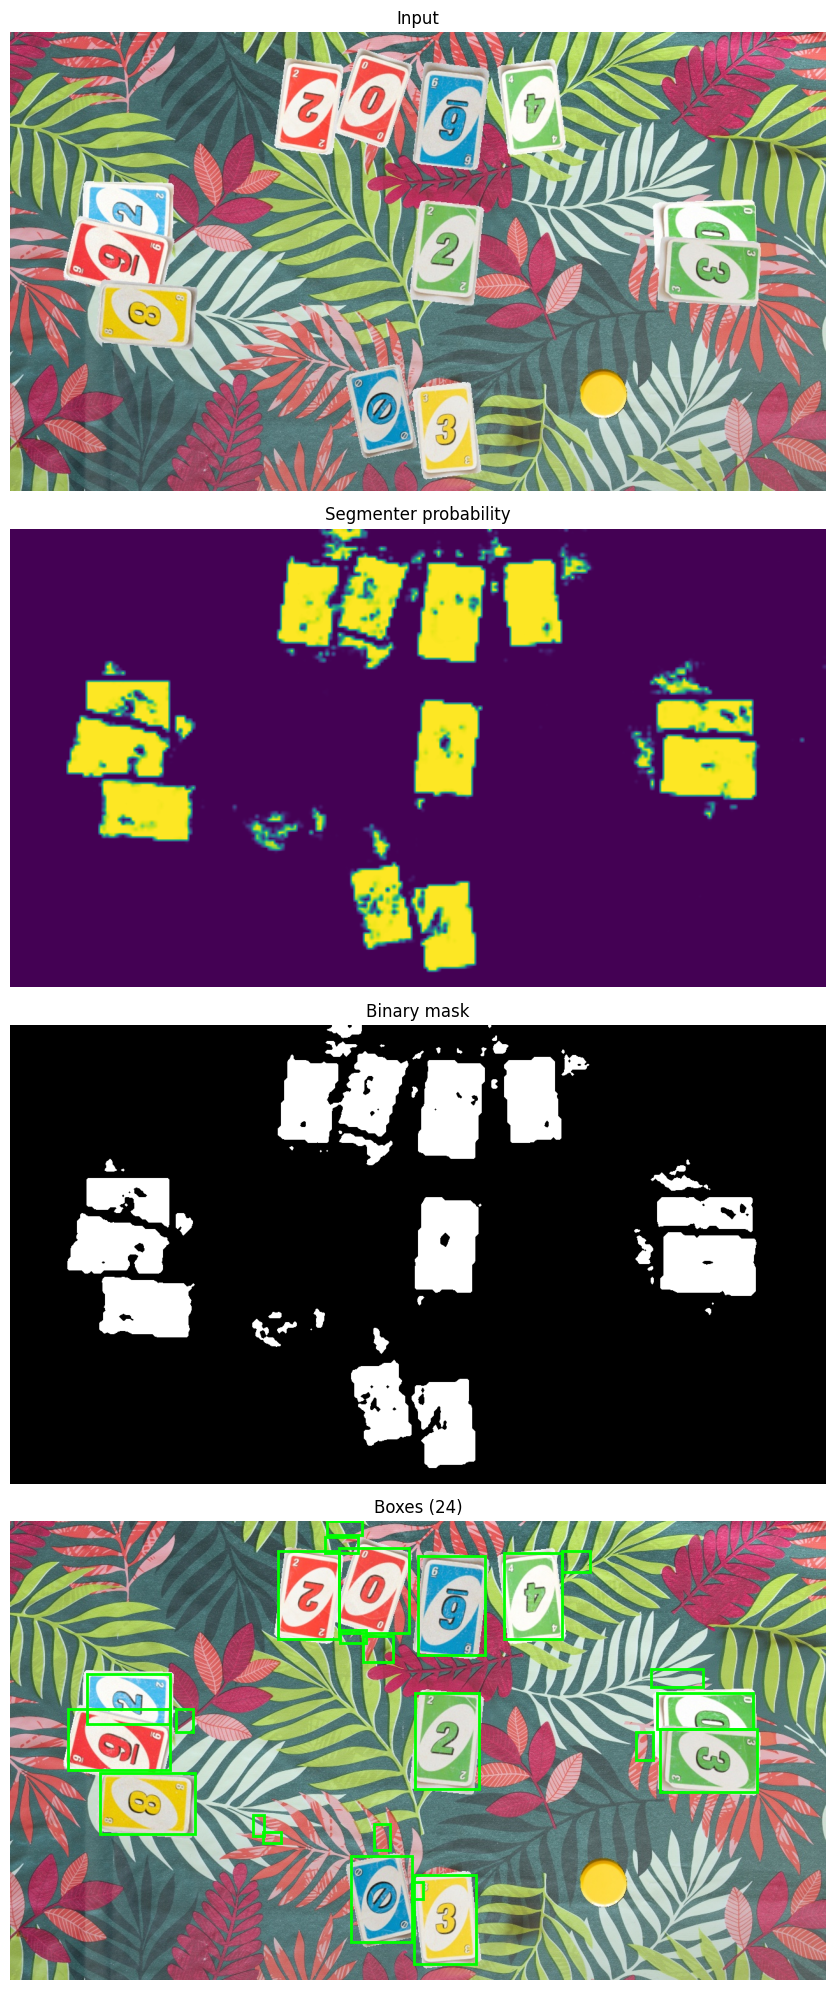

Predictions:
  box 00 (640, 55, 745, 210) -> b_6 [p3] conf=0.38
  box 01 (90, 295, 250, 390) -> r_9 [p4] conf=0.07
  box 02 (1020, 325, 1171, 425) -> g_3 [p2] conf=0.64
  box 03 (635, 270, 735, 420) -> g_2 [center] conf=0.65
  box 04 (515, 41, 625, 175) -> r_0 [p3] conf=0.29
  box 05 (140, 395, 290, 490) -> y_8 [p4] conf=0.64
  box 06 (634, 555, 730, 695) -> y_3 [p1] conf=0.49
  box 07 (420, 46, 516, 185) -> r_2 [p3] conf=0.36
  box 08 (535, 525, 630, 660) -> b_skip [p1] conf=0.52
  box 09 (775, 50, 865, 185) -> g_4 [p3] conf=0.31
  box 10 (120, 240, 250, 318) -> b_2 [p4] conf=0.36
  box 11 (1015, 270, 1165, 325) -> g_1 [p2] conf=0.05
  box 12 (1005, 231, 1087, 260) -> y_1 [p2] conf=0.05
  box 13 (554, 180, 600, 220) -> g_draw_2 [p3] conf=0.04
  box 14 (865, 46, 909, 80) -> y_7 [p3] conf=0.07
  box 15 (494, 25, 545, 50) -> draw_4 [p3] conf=0.06
  box 16 (981, 330, 1009, 375) -> wild [p2] conf=0.06
  box 17 (497, 0, 552, 21) -> y_reverse [p3] conf=0.05
  box 18 (570, 475, 595, 516) -> r

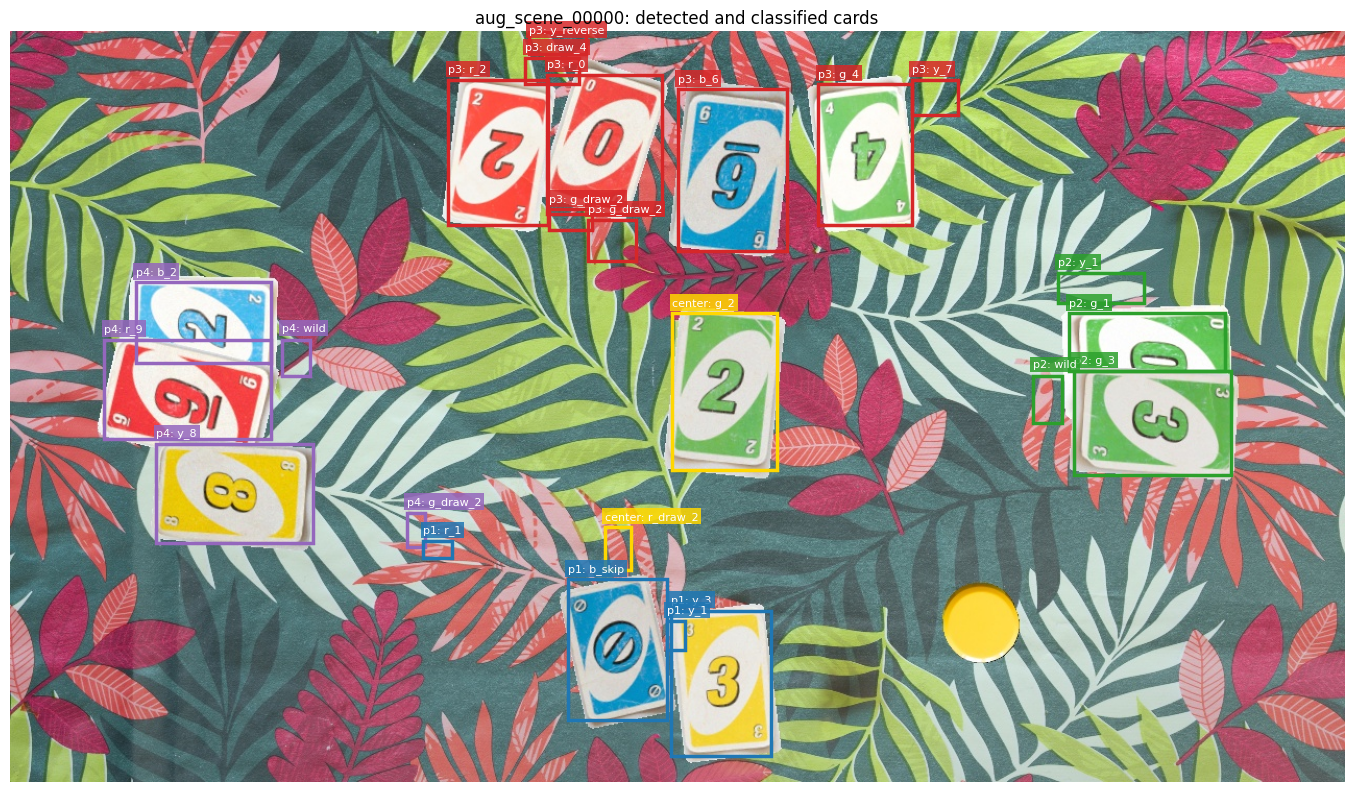


Matched IoU >= 0.30: 12 / 24
Label accuracy on matched boxes:        91.7%
Owner/region accuracy on matched boxes: 100.0%

First matched rows:
  pred=p3     b_6          | truth=p3     b_6          | IoU=0.80
  pred=p4     r_9          | truth=p4     r_9          | IoU=0.66
  pred=p2     g_3          | truth=p2     g_3          | IoU=0.85
  pred=center g_2          | truth=center g_2          | IoU=0.78
  pred=p3     r_0          | truth=p3     r_0          | IoU=0.75
  pred=p4     y_8          | truth=p4     y_8          | IoU=0.81
  pred=p1     y_3          | truth=p1     y_3          | IoU=0.81
  pred=p3     r_2          | truth=p3     r_2          | IoU=0.81
  pred=p1     b_skip       | truth=p1     b_skip       | IoU=0.77
  pred=p3     g_4          | truth=p3     g_4          | IoU=0.75
  pred=p4     b_2          | truth=p4     b_2          | IoU=0.75
  pred=p2     g_1          | truth=p2     g_0          | IoU=0.46
  pred=p2     y_1          | truth=p1     b_skip       | IoU=0.0

{'image_id': 'aug_scene_00000',
 'center_card': 'g_2',
 'active_player': 'p1',
 'player_1_cards': 'y_3;b_skip;r_1;y_1',
 'player_2_cards': 'g_3;g_1;y_1;wild',
 'player_3_cards': 'b_6;r_0;r_2;g_4;g_draw_2;y_7;draw_4;y_reverse;g_draw_2',
 'player_4_cards': 'r_9;y_8;b_2;wild;g_draw_2'}

In [5]:
state = run_single_image_diagnostics(state)
state["summary"]


## Benchmark on the original labeled dataset

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes the worst and top performing examples.

In [ ]:
benchmark = run_labeled_benchmark(
    state,
    benchmark_config=BENCHMARK_CFG,
)
{k: benchmark[k] for k in ("center_acc", "p1_f1", "p2_f1", "p3_f1", "p4_f1", "macro_f1", "overall")}

Evaluating on 71 labeled original images from /Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train.csv...
